In [34]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:


# let's consider all the avialale evaluation results and make a comparison framefirst, and then plot

def extract_the_paths(k, pos_samples, neg_samples):

    dataset = ["bill","wikitext"]
    model = ["lda","ctm","bertopic"]
    num_clusters = k #[50] # 50, 100
    sampling_strategy = ["top_k","weighted"]
    pos_samples = pos_samples # [10]
    #neg_samples = [0, 3]

    #constrcut the path basd on the combination of those variables
    all_eval_results_paths = []
    for d in dataset:
        for m in model:
            for n in num_clusters:
                for s in sampling_strategy:
                    for p in pos_samples:
                        #for neg in neg_samples:
                        # actually the weighted sampling has _1, _ 2, and _3, and the top_k has only _1
                        if s == "weighted":
                            suffixes = ["_1", "_2", "_3"]
                        else:
                            suffixes = ["_1"]
                        for suffix in suffixes:
                            eval_path = f"/Users/viktor/Desktop/PMLR/output/eval_result/{d}/{d}_{m}_{n}_{s}_pos{p}_neg0{suffix}.json"
                            if os.path.exists(eval_path):
                                all_eval_results_paths.append((eval_path, d, m, n, s, p, suffix))
                            else:
                                print(f"Path does not exist: {eval_path}")

    #check how many combinations we use:
    print(f"Total evaluation result files found: {len(all_eval_results_paths)}")

    return all_eval_results_paths

# let's record the 3 metrics of those runs, use the extract_metrics_and_compute_average function
# lets write a function that takes in the eval_results_path and returns a dictionary with the metrics and the df

def extract_all_metrics_and_plot(all_eval_results_paths):

    def extract_metrics_and_compute_average(eval_results_path, p):
        # we receive the loaded json and extract the metrics and return 3 metrics as floats numbers 
        with open(eval_results_path, 'r') as f:
            eval_result = json.load(f)
        consistency = eval_result['scores']['consistency']
        generalization = eval_result['scores']['generalization']
        distinctiveness = eval_result['scores']['distinctiveness']
        # let's also print out the length of each metric list, if it is not the same as the number of clusters, we have a problem
        if len(consistency) != p:
            print(f"Warning: Length of consistency list ({len(consistency)}) does not match pos_samples ({p}) in file {eval_results_path}")
        if len(generalization) != p:
            print(f"Warning: Length of generalization list ({len(generalization)}) does not match pos_samples ({p}) in file {eval_results_path}")
        if len(distinctiveness) != p:
            print(f"Warning: Length of distinctiveness list ({len(distinctiveness)}) does not match pos_samples ({p}) in file {eval_results_path}") 
        # compute averages
        avg_consistency = sum(consistency) / len(consistency) if len(consistency) > 0 else 0
        avg_generalization = sum(generalization) / len(generalization) if len(generalization) > 0 else 0
        avg_distinctiveness = sum(distinctiveness) / len(distinctiveness) if len(distinctiveness) > 0 else 0
        return avg_consistency, avg_generalization, avg_distinctiveness

    records = []
    for eval_path, d, m, n, s, p, suffix in all_eval_results_paths:
        avg_consistency, avg_generalization, avg_distinctiveness = extract_metrics_and_compute_average(eval_path, p)
        records.append({
            "dataset": d,
            "model": m,
            "num_clusters": n,
            "sampling_strategy": s,
            "pos_samples": p,
            "suffix": suffix,
            "avg_consistency": avg_consistency,
            "avg_generalization": avg_generalization,
            "avg_distinctiveness": avg_distinctiveness
        })
    # create a dataframe
    df_metrics = pd.DataFrame(records)

    df_avg_metrics = df_metrics.groupby(['dataset', 'model', 'num_clusters', 'sampling_strategy', 'pos_samples']).agg({
    'avg_consistency': 'mean',
    'avg_generalization': 'mean',
    'avg_distinctiveness': 'mean'
    }).reset_index()

    
    df = df_avg_metrics.copy()

    # Ensure dataset names are correct
    df["dataset"] = df["dataset"].str.lower()
    datasets = ["bill", "wikitext"]  # must match df exactly
    models = ["lda", "ctm", "bertopic"]

    # Metric → marker mapping
    metrics = {
        "avg_consistency": ("Consistency", "o"),
        "avg_generalization": ("Generalization", "*"),
        "avg_distinctiveness": ("1 - Distinctiveness", "^")
    }

    colors = {"top_k": "red", "weighted": "blue"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    fig.suptitle(f"Positive samples: {df['pos_samples'].unique().item()}", fontsize=16)

    for ax, dataset in zip(axes, datasets):
        data = df[df["dataset"] == dataset]
        
        for i, model in enumerate(models):
            subset = data[data["model"] == model]

            for _, row in subset.iterrows():
                # Offset x slightly depending on sampling strategy
                x = i + (-0.12 if row["sampling_strategy"] == "top_k" else 0.12)

                for metric, (label, marker) in metrics.items():
                    y = row[metric]
                    if metric == "avg_distinctiveness":
                        y = 1 - y  # invert so higher=better

                    ax.scatter(x, y, 
                            color=colors[row["sampling_strategy"]],
                            marker=marker, 
                            s=100, 
                            edgecolors="black")
                    # Add annotated score text
                    ax.text(x, y + 0.01, f"{y:.2f}",
                            ha="center", va="bottom", fontsize=9)

        ax.set_title(dataset, fontsize=14)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, fontsize=12)
        ax.set_ylabel("Score (higher = better)", fontsize=12)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    # Create legends
    color_legend = [
        plt.Line2D([0], [0], marker='o', color='red', linestyle='',
                markerfacecolor='red', markersize=10, label='top_k'),
        plt.Line2D([0], [0], marker='o', color='blue', linestyle='',
                markerfacecolor='blue', markersize=10, label='weighted')
    ]

    shape_legend = [
        plt.Line2D([0], [0], marker=marker, color='black', linestyle='',
                markersize=12, label=label)
        for metric, (label, marker) in metrics.items()
    ]

    axes[1].legend(handles=color_legend + shape_legend, 
                title="Legend", 
                loc="upper right", 
                fontsize=10, 
                title_fontsize=11,
                framealpha=0.9)

    plt.tight_layout()
    plt.show()

    return df


Total evaluation result files found: 24
Total evaluation result files found: 24
Total evaluation result files found: 24
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 23
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length

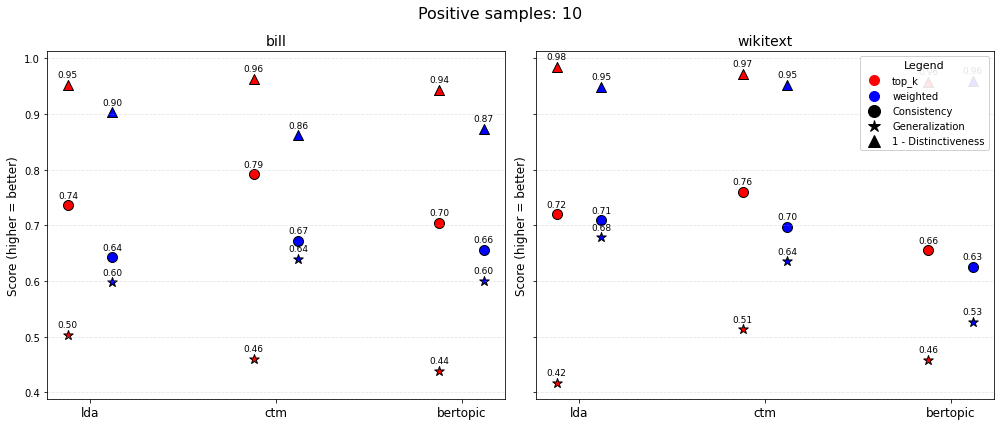

Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 23
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency 

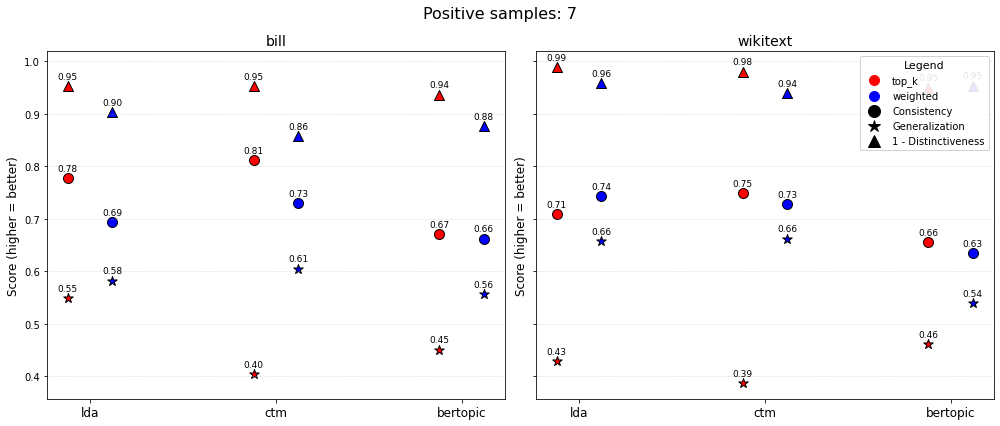

Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency length: 23
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 22
Generalization length: 22
Distinctiveness length: 25
Consistency length: 25
Generalization length: 25
Distinctiveness length: 25
Consistency 

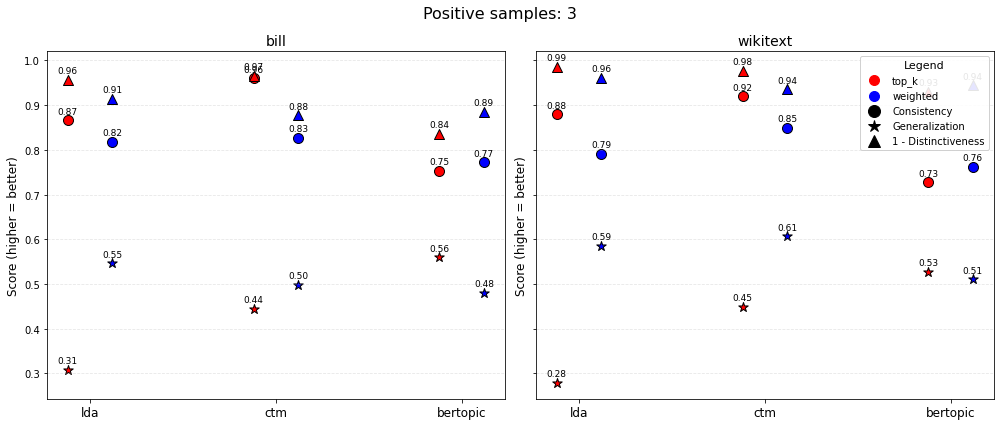

In [50]:
all_eval_results_paths_pos_10 = extract_the_paths(k=[25], pos_samples=[10], neg_samples=[0])
all_eval_results_paths_pos_7 = extract_the_paths(k=[25], pos_samples=[7], neg_samples=[0])
all_eval_results_paths_pos_3 = extract_the_paths(k=[25], pos_samples=[3], neg_samples=[0])

df_pos_10 = extract_all_metrics_and_plot(all_eval_results_paths_pos_10)
df_pos_7 = extract_all_metrics_and_plot(all_eval_results_paths_pos_7)
df_pos_3 = extract_all_metrics_and_plot(all_eval_results_paths_pos_3)

Path does not exist: /Users/viktor/Desktop/PMLR/output/eval_result/wikitext/wikitext_lda_50_weighted_pos10_neg0_1.json
Path does not exist: /Users/viktor/Desktop/PMLR/output/eval_result/wikitext/wikitext_ctm_50_weighted_pos10_neg0_2.json
Total evaluation result files found: 22
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 50
Distinctiveness length: 50
Consistency length: 50
Generalization length: 49
Distinctiveness length: 50
Consistency length: 50
Generalization 

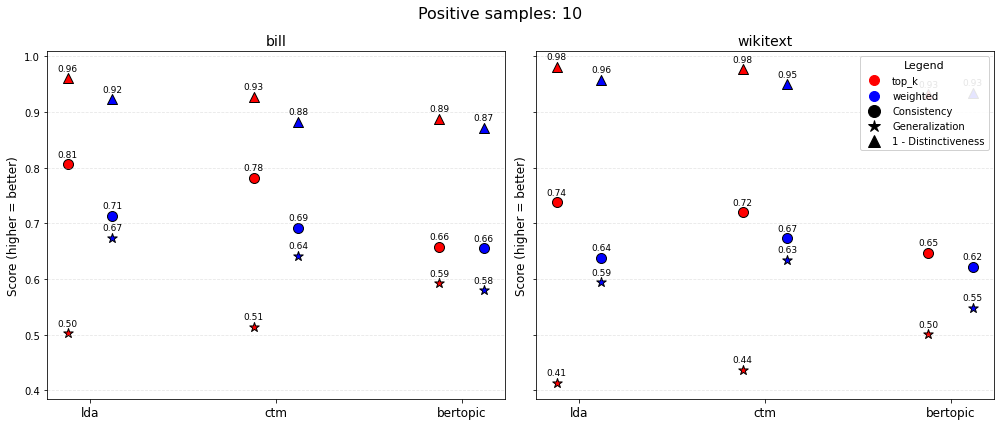

In [51]:
all_eval_results_paths_k_50_pos_10 = extract_the_paths(k=[50], pos_samples=[10], neg_samples=[0])

df_k_50_pos_10 = extract_all_metrics_and_plot(all_eval_results_paths_k_50_pos_10)